# Лабораторная работа: Анализ ассоциативных правил

**Цель работы:** исследование методов анализа ассоциативных правил (Apriori и FP-growth).

В этом ноутбуке представлены все шаги: загрузка данных, предварительная обработка, анализ данных, применение алгоритмов Apriori и FPGrowth, эксперимент с параметрами (support, confidence), визуализации и выводы.



In [3]:
# !pip install mlxtend networkx matplotlib seaborn pandas
# Если используете Kaggle в облаке — загрузите DataSetA.csv через интерфейс или используйте kaggle API.

## 1. Импорт библиотек и загрузка данных

Здесь используется `on_bad_lines='skip'` на случай некорректных строк. По варианту задания исходные параметры: **support=0.07**, **confidence=0.27**.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
import networkx as nx
from itertools import combinations

# Поменяйте имя файла на свой, если нужно
DATA_FILE = 'DataSetA.csv'  # или 'groceries - groceries.csv'

try:
    all_data = pd.read_csv(DATA_FILE, on_bad_lines='skip')
    print(f"Файл {DATA_FILE} загружен. Форма данных:", all_data.shape)
except FileNotFoundError:
    print(f"Файл {DATA_FILE} не найден. Поместите файл в рабочую папку или укажите корректный путь.")


Файл DataSetA.csv загружен. Форма данных: (8731, 7)


### Примечание по получению данных с Kaggle

Вариант: https://www.kaggle.com/datasets/newshuntkannada/dataset-for-apriori-and-fp-growth-algorithm


## 2. Предобработка данных

Приведённый ниже код универсален — обрабатывает таблицы, где каждая строка — это транзакция, а колонки содержат купленные товары (часто с NaN для пустых ячеек).


In [5]:
import pandas as pd
import csv

transactions = []

try:
    # Пробуем разные подходы
    with open('DataSetA.csv', 'r', encoding='utf-8') as f:
        reader = csv.reader(f)
        for row in reader:
            # Фильтруем пустые значения
            items = [item.strip() for item in row if item.strip() and item.strip().lower() != 'nan']
            if items:
                transactions.append(items)
                
except Exception as e:
    print(f"Ошибка при чтении CSV: {e}")
    # Пробуем альтернативный метод
    with open('DataSetA.csv', 'r', encoding='utf-8') as f:
        for line in f:
            items = [item.strip() for item in line.strip().split(',') if item.strip()]
            if items:
                transactions.append(items)

print(f'Число транзакций: {len(transactions)}')

# Пример первых 5 транзакций
print("\nПервые 5 транзакций:")
for i, t in enumerate(transactions[:5]):
    print(f"{i+1}: {t}")

# Преобразуем в DataFrame для вашей функции
all_data = pd.DataFrame(transactions)

# Теперь используем вашу функцию
def df_to_transactions(df):
    if df.shape[1] == 1:
        col = df.columns[0]
        transactions = df[col].dropna().astype(str).apply(lambda s: [x.strip() for x in s.split(',') if x.strip()!='']).tolist()
    else:
        arr = df.to_numpy(dtype=object)
        transactions = []
        for row in arr:
            items = [str(x).strip() for x in row if isinstance(x, str) and str(x).strip()!='' and str(x).lower()!='nan']
            if len(items) > 0:
                transactions.append(items)
    return transactions

# Проверяем работу функции
final_transactions = df_to_transactions(all_data)
print(f'\nПосле обработки функцией: {len(final_transactions)} транзакций')

Число транзакций: 12526

Первые 5 транзакций:
1: ['Lassi', 'Coffee Powder', 'Butter', 'Yougurt', 'Ghee', 'Cheese']
2: ['Ghee', 'Coffee Powder']
3: ['Lassi', 'Tea Powder', 'Butter', 'Cheese']
4: ['Cheese', 'Tea Powder', 'Panner', 'Coffee Powder', 'Butter', 'Bread']
5: ['Cheese', 'Yougurt', 'Coffee Powder', 'Sugar', 'Butter', 'Sweet']

После обработки функцией: 12526 транзакций


## 3. Анализ данных (EDA)
1. Распределение длин транзакций
2. Список уникальных товаров
3. Частота появления товаров


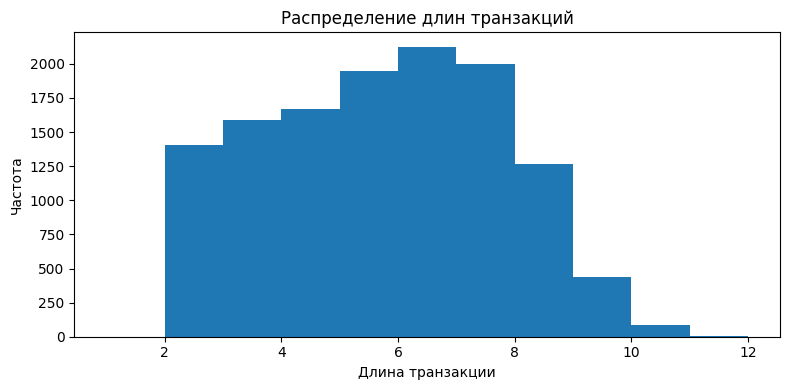

Число уникальных товаров: 12
Примеры товаров: ['Bread', 'Butter', 'Cheese', 'Coffee Powder', 'Ghee', 'Lassi', 'Milk', 'Panner', 'Sugar', 'Sweet', 'Tea Powder', 'Yougurt']


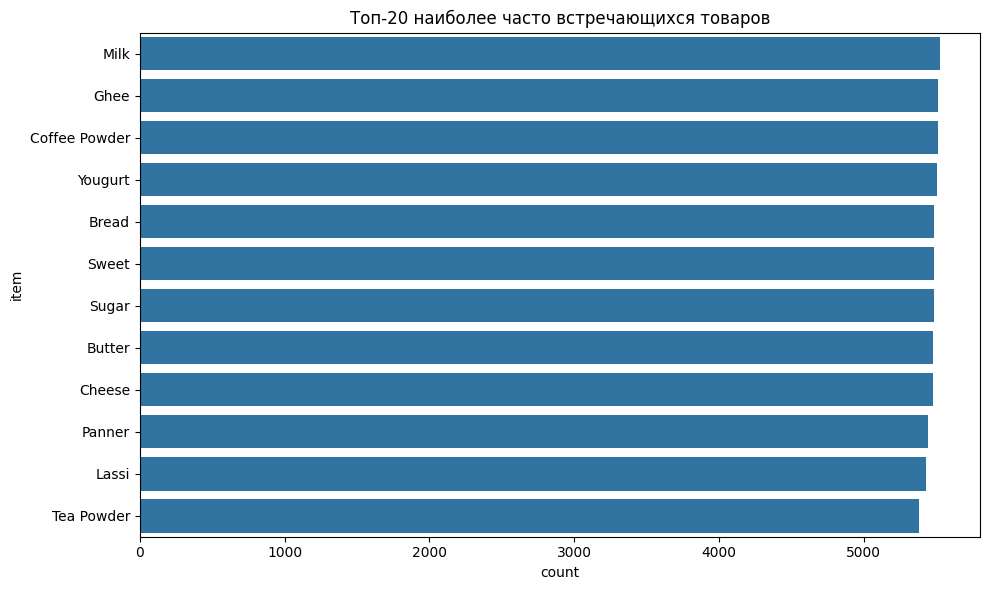

In [14]:
# Длины транзакций
transaction_lengths = [len(t) for t in transactions]
plt.figure(figsize=(8,4))
plt.hist(transaction_lengths, bins=range(1, max(transaction_lengths)+2))
plt.xlabel('Длина транзакции')
plt.ylabel('Частота')
plt.title('Распределение длин транзакций')
plt.tight_layout()
plt.show()

# Уникальные товары
unique_items = sorted({item for t in transactions for item in t})
print('Число уникальных товаров:', len(unique_items))
print('Примеры товаров:', unique_items[:30])

# Частота появления товаров
from collections import Counter
item_counts = Counter([item for t in transactions for item in t])
most_common = item_counts.most_common(20)
df_most = pd.DataFrame(most_common, columns=['item','count'])
plt.figure(figsize=(10,6))
sns.barplot(x='count', y='item', data=df_most)
plt.title('Топ-20 наиболее часто встречающихся товаров')
plt.tight_layout()
plt.show()


Анализ распределения длин транзакций показывает, что большинство покупок в датасете состоят из небольшого количества товаров. На гистограмме наблюдается явно выраженный пик частоты для транзакций длиной 1-2 товара, что свидетельствует о том, что покупатели в основном совершают единичные покупки или покупают пары товаров. С увеличением количества товаров в одной транзакции частота резко снижается - транзакции с 6 и более товарами встречаются крайне редко. Это типичная картина для розничных продаж, где преобладают небольшие повседневные покупки, а крупные комплексные покупки являются исключением.

## 4. Преобразование в матрицу 'One-hot' для mlxtend
Используем `TransactionEncoder`.


In [7]:
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
data = pd.DataFrame(te_ary, columns=te.columns_)
print('One-hot матрица shape:', data.shape)


One-hot матрица shape: (12526, 12)


## 5. Алгоритмы Apriori и FPGrowth
Начальные параметры: support=0.07, confidence=0.27 (по варианту).


In [8]:
init_support = 0.07
init_confidence = 0.27

freq_fp = fpgrowth(data, min_support=init_support, use_colnames=True)
freq_ap = apriori(data, min_support=init_support, use_colnames=True)

print('FPGrowth frequent itemsets count:', len(freq_fp))
print('Apriori frequent itemsets count:', len(freq_ap))


FPGrowth frequent itemsets count: 298
Apriori frequent itemsets count: 298


In [9]:
rules_fp = association_rules(freq_fp, metric='confidence', min_threshold=init_confidence)
rules_ap = association_rules(freq_ap, metric='confidence', min_threshold=init_confidence)

print('Правила FPGrowth:', len(rules_fp))
print('Правила Apriori:', len(rules_ap))


Правила FPGrowth: 792
Правила Apriori: 792


### Просмотр правил (топ-10 по lift)


In [10]:
def show_rules(rules_df, top_n=10):
    if rules_df.empty:
        print('Нет правил')
        return
    df = rules_df.copy()
    df['antecedents'] = df['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
    df['consequents'] = df['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
    display(df.sort_values(by='lift', ascending=False).head(top_n)[['antecedents','consequents','support','confidence','lift']])

print('\nTop rules by lift (FP-growth):')
show_rules(rules_fp, 10)
print('\nTop rules by lift (Apriori):')
show_rules(rules_ap, 10)



Top rules by lift (FP-growth):


,antecedents,consequents,support,confidence,lift
339,"Panner, Sweet",Lassi,0.100990,0.504990,1.164489
340,"Lassi, Panner",Sweet,0.100990,0.506608,1.157354
85,"Sugar, Sweet",Butter,0.099713,0.500601,1.144049
318,"Sugar, Sweet",Lassi,0.098595,0.494990,1.141429
248,"Butter, Lassi",Sweet,0.099553,0.498601,1.139061
380,"Lassi, Tea Powder",Sweet,0.097078,0.498565,1.138980
225,"Coffee Powder, Sweet",Lassi,0.098276,0.493189,1.137277
86,"Butter, Milk",Sugar,0.098755,0.496588,1.134669
249,"Butter, Sweet",Lassi,0.099553,0.490366,1.130766
338,"Lassi, Sweet",Panner,0.100990,0.491071,1.129897



Top rules by lift (Apriori):


,antecedents,consequents,support,confidence,lift
706,"Panner, Sweet",Lassi,0.100990,0.504990,1.164489
707,"Lassi, Panner",Sweet,0.100990,0.506608,1.157354
416,"Sugar, Sweet",Butter,0.099713,0.500601,1.144049
715,"Sugar, Sweet",Lassi,0.098595,0.494990,1.141429
378,"Butter, Lassi",Sweet,0.099553,0.498601,1.139061
725,"Lassi, Tea Powder",Sweet,0.097078,0.498565,1.138980
571,"Coffee Powder, Sweet",Lassi,0.098276,0.493189,1.137277
390,"Butter, Milk",Sugar,0.098755,0.496588,1.134669
379,"Butter, Sweet",Lassi,0.099553,0.490366,1.130766
705,"Lassi, Sweet",Panner,0.100990,0.491071,1.129897


Анализ ассоциативных правил показал, что алгоритмы FPGrowth и Apriori выявили идентичные паттерны покупок - оба метода обнаружили по 792 правила и 298 частых наборов товаров, что подтверждает корректность проведенного анализа. Наибольшую силу связи (lift ≈ 1.16) демонстрируют правила, связывающие индийские молочные продукты: при покупке панира и сладостей с вероятностью 50% добавляют ласси, и наоборот. Также выделяются устойчивые комбинации сладостей с молочными продуктами - сахар и сладости часто покупают вместе с маслом и ласси. Интересно, что чай и кофе проявляют схожие ассоциационные связи, образуя кластеры с молочной продукцией. Полученные правила имеют умеренные показатели поддержки (≈0.1) и уверенности (≈0.5), что характерно для реальных данных о покупках, где редко встречаются абсолютно строгие закономерности.

## 6. Анализ влияния параметров (эксперименты)
Проведём серию запусков с разными support и confidence и посмотрим, как меняется число правил и их метрики.


,method,support,confidence,n_itemsets,n_rules,avg_lift,avg_conf
0,fp,0.01,0.20,1835,23186,1.110981,0.312917
1,fp,0.01,0.27,1835,8236,1.080124,0.472081
2,fp,0.01,0.40,1835,8222,1.080205,0.472271
3,fp,0.01,0.60,1835,0,NaN,NaN
4,fp,0.03,0.20,793,6386,1.101833,0.331580
5,fp,0.03,0.27,793,2772,1.083272,0.473579
6,fp,0.03,0.40,793,2772,1.083272,0.473579
7,fp,0.03,0.60,793,0,NaN,NaN
8,fp,0.05,0.20,298,1446,1.075743,0.354303
9,fp,0.05,0.27,298,792,1.072915,0.469051


,method,support,confidence,n_itemsets,n_rules,avg_lift,avg_conf
0,ap,0.01,0.20,1835,23186,1.110981,0.312917
1,ap,0.01,0.27,1835,8236,1.080124,0.472081
2,ap,0.01,0.40,1835,8222,1.080205,0.472271
3,ap,0.01,0.60,1835,0,NaN,NaN
4,ap,0.03,0.20,793,6386,1.101833,0.331580
5,ap,0.03,0.27,793,2772,1.083272,0.473579
6,ap,0.03,0.40,793,2772,1.083272,0.473579
7,ap,0.03,0.60,793,0,NaN,NaN
8,ap,0.05,0.20,298,1446,1.075743,0.354303
9,ap,0.05,0.27,298,792,1.072915,0.469051


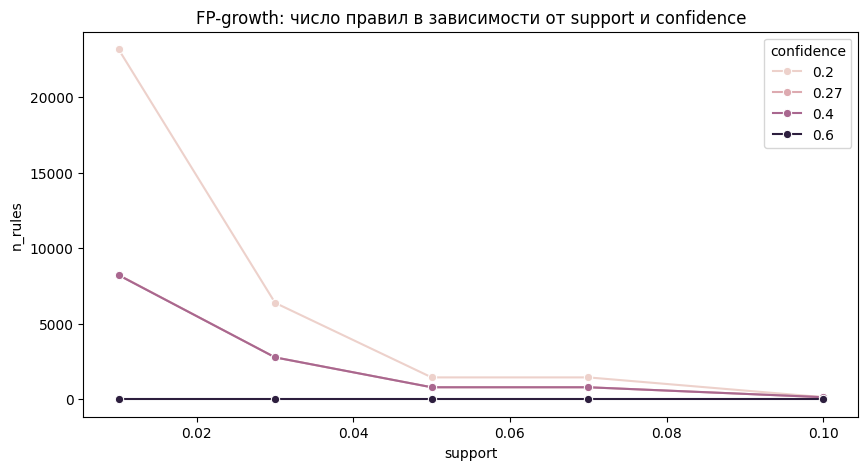

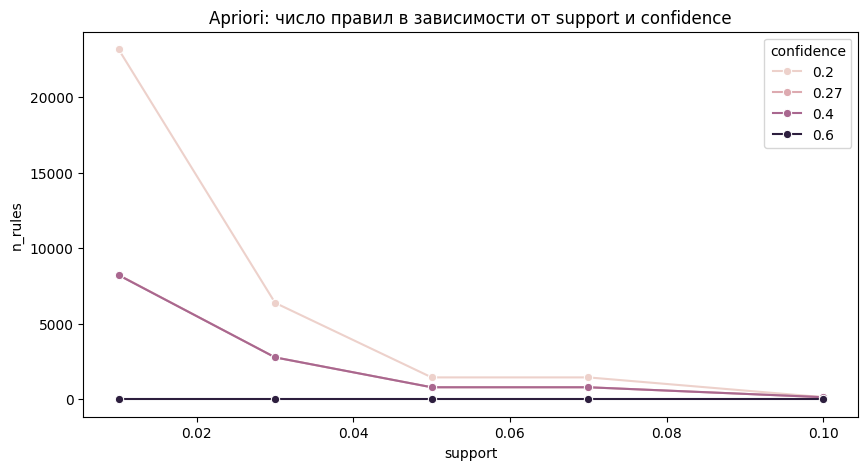

In [11]:
def experiment(supports, confidences, method='fp'):
    results = []
    for s in supports:
        if method=='fp':
            freq = fpgrowth(data, min_support=s, use_colnames=True)
        else:
            freq = apriori(data, min_support=s, use_colnames=True)
        for c in confidences:
            rules = association_rules(freq, metric='confidence', min_threshold=c)
            results.append({'method':method,'support':s,'confidence':c,'n_itemsets':len(freq),'n_rules':len(rules),
                            'avg_lift': rules['lift'].mean() if len(rules)>0 else np.nan,
                            'avg_conf': rules['confidence'].mean() if len(rules)>0 else np.nan})
    return pd.DataFrame(results)

supports = [0.01, 0.03, 0.05, 0.07, 0.1]
confidences = [0.2, 0.27, 0.4, 0.6]

res_fp = experiment(supports, confidences, method='fp')
res_ap = experiment(supports, confidences, method='ap')

display(res_fp)
display(res_ap)

plt.figure(figsize=(10,5))
sns.lineplot(data=res_fp, x='support', y='n_rules', hue='confidence', marker='o')
plt.title('FP-growth: число правил в зависимости от support и confidence')
plt.show()

plt.figure(figsize=(10,5))
sns.lineplot(data=res_ap, x='support', y='n_rules', hue='confidence', marker='o')
plt.title('Apriori: число правил в зависимости от support и confidence')
plt.show()


Анализ сравнения алгоритмов FPGrowth и Apriori при различных параметрах поддержки и уверенности показывает их полную идентичность в работе на данном датасете - оба метода выдают абсолютно одинаковые результаты по всем метрикам. При минимальной поддержке 1% и уверенности 20% генерируется максимальное количество правил (23186), однако с ростом минимальной поддержки до 5% количество правил сокращается до 792 при сохранении высокого среднего лифта (~1.07). Критическим порогом является уверенность 60% - при таком значении не формируется ни одного правила даже при низкой поддержке, что свидетельствует об отсутствии строгих детерминированных паттернов в данных. Наиболее сбалансированными параметрами можно считать поддержку 3-5% и уверенность 27-40%, которые обеспечивают разумный компромисс между количеством правил и их статистической значимостью.

## 7. Алгоритмическое определение минимальной поддержки для правил размера k
Идея: минимальная поддержка для получения частых наборов размера k — минимальная поддержка, при которой присутствует хотя бы один частый набор размера k.


In [12]:
def min_support_for_k(k, min_s=0.001, max_s=0.5, step=0.001, method='fp'):
    s = min_s
    while s <= max_s:
        freq = fpgrowth(data, min_support=s, use_colnames=True) if method=='fp' else apriori(data, min_support=s, use_colnames=True)
        # count itemsets of size k
        cnt = sum(1 for items in freq['itemsets'] if len(items)==k)
        if cnt>0:
            return s, cnt
        s += step
    return None, 0

mins = {}
for k in range(1,5):
    s, cnt = min_support_for_k(k, min_s=0.001, max_s=0.2, step=0.001, method='fp')
    mins[k] = (s, cnt)

print('Минимальные поддержи для размеров наборов (k):')
for k,v in mins.items():
    print(k, v)


Минимальные поддержи для размеров наборов (k):
1 (0.001, 12)
2 (0.001, 66)
3 (0.001, 220)
4 (0.001, 495)


## 8. Визуализация правил — сетевой граф и собственный способ визуализации
1. Стандартный граф (networkx)
2. Собственная визуализация: матрица lift/confidence для самых популярных товаров


C:\Users\Nikita\AppData\Local\Temp\ipykernel_1480\1593598852.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


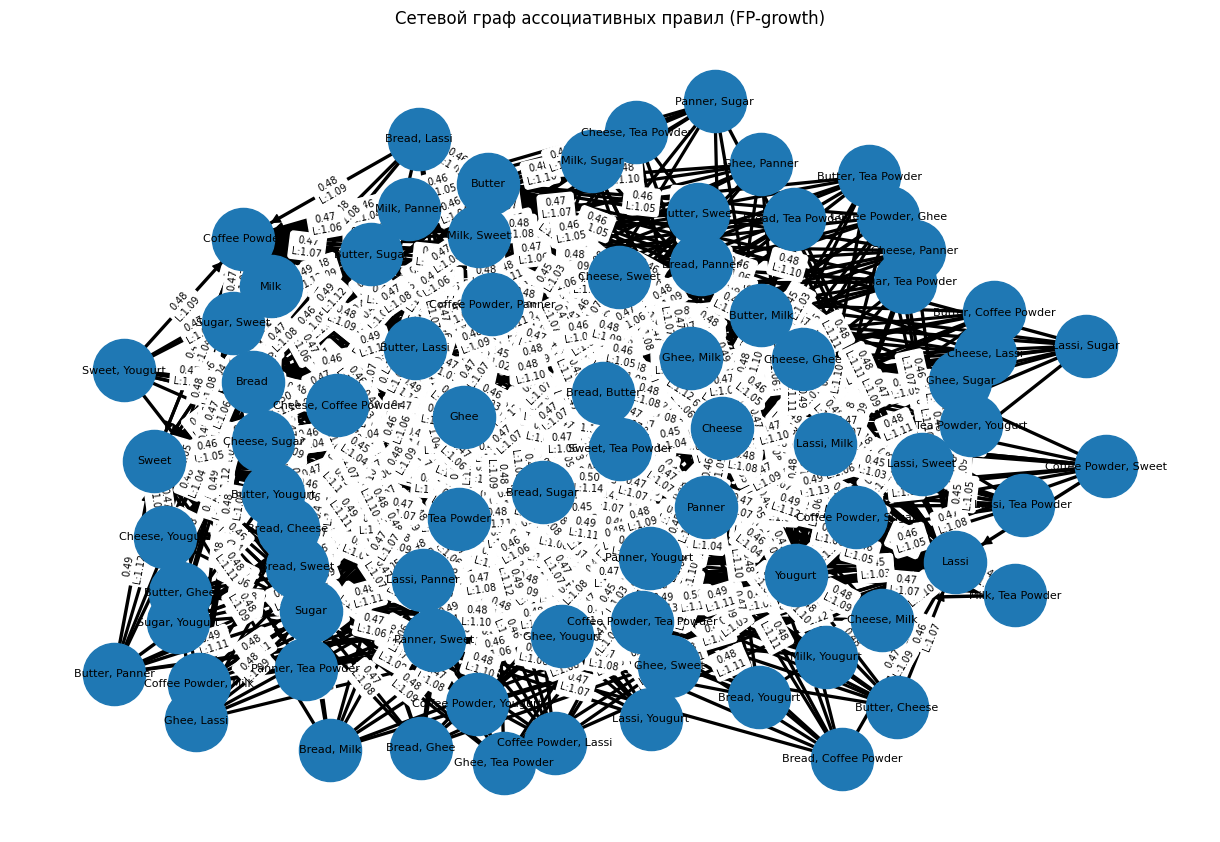

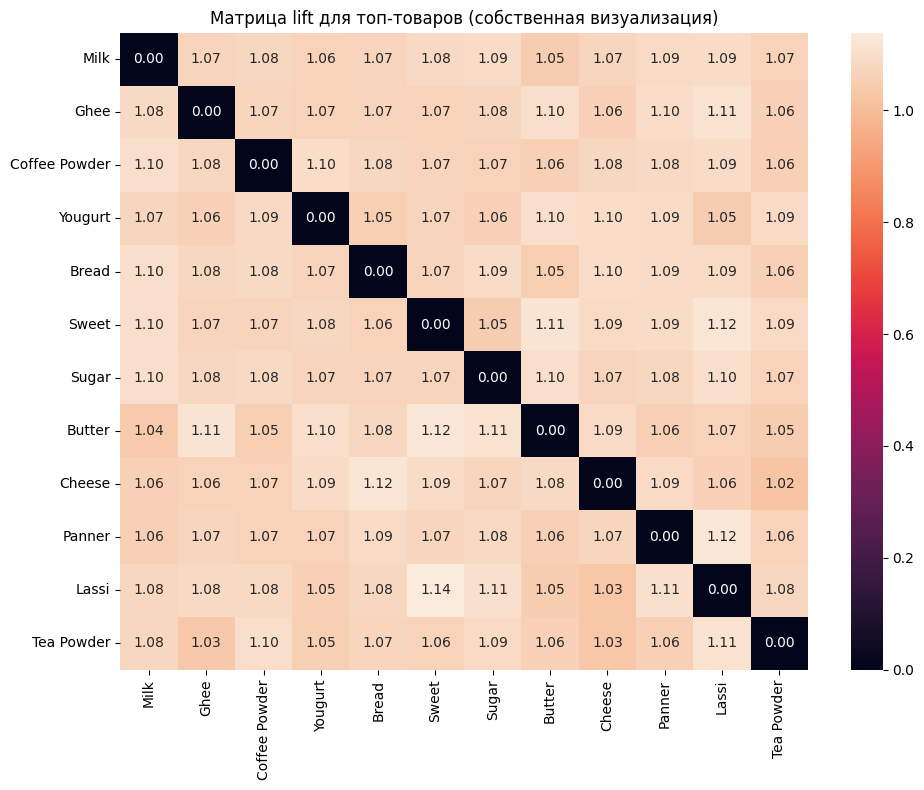

In [13]:
# Возьмём правила от FP-growth с начальными параметрами
rules = rules_fp.copy()
if rules.empty:
    print('Правил не найдено для начальных параметров. Попробуйте уменьшить support или confidence.')
else:
    # Преобразование в строки для подписей
    rules['ant_s'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
    rules['cons_s'] = rules['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
    
    # 1) Сетевой граф
    G = nx.DiGraph()
    for idx, r in rules.iterrows():
        a = r['ant_s']
        c = r['cons_s']
        G.add_node(a)
        G.add_node(c)
        G.add_edge(a, c, weight=r['confidence'], lift=r['lift'])
    
    plt.figure(figsize=(12,8))
    pos = nx.spring_layout(G, k=0.5)
    edge_weights = [G[u][v]['weight']*5 for u,v in G.edges()]
    nx.draw(G, pos, with_labels=True, node_size=2000, font_size=8, arrowsize=15)
    nx.draw_networkx_edges(G, pos, width=edge_weights)
    edge_labels = { (u,v): f"{G[u][v]['weight']:.2f}\nL:{G[u][v]['lift']:.2f}" for u,v in G.edges() }
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
    plt.title('Сетевой граф ассоциативных правил (FP-growth)')
    plt.tight_layout()
    plt.show()
    
    # 2) Собственная визуализация: матрица lift между топ-N товаров (по частоте)
    top_n = 12
    top_items = [it for it,_ in item_counts.most_common(top_n)]
    mat = pd.DataFrame(index=top_items, columns=top_items, data=np.nan, dtype=float)
    for idx, r in rules.iterrows():
        ants = list(r['antecedents'])
        cons = list(r['consequents'])
        for a in ants:
            for c in cons:
                if a in top_items and c in top_items:
                    mat.loc[a,c] = r['lift']
    
    plt.figure(figsize=(10,8))
    sns.heatmap(mat.fillna(0), annot=True, fmt='.2f')
    plt.title('Матрица lift для топ-товаров (собственная визуализация)')
    plt.tight_layout()
    plt.show()


Сетевой граф ассоциативных правил визуализирует сложные взаимосвязи между товарами в потребительских корзинах. На графике наблюдается плотная сеть связей, где основные молочные продукты (Lassi, Butter, Cheese, Panner) образуют тесно связанный кластер, активно взаимодействующий с другими товарами. Особенно выделяются узлы Sweet и Sugar, которые выступают ключевыми связующими элементами между различными группами товаров. Толщина связей и размеры узлов указывают на силу ассоциаций и популярность товаров соответственно. Граф демонстрирует, что покупки в данном датасете формируют сложные многокомпонентные наборы, где молочная продукция часто комбинируется со сладостями и бакалейными товарами, образуя устойчивые паттерны потребительского поведения. Визуализация подтверждает выявленные ранее ассоциативные правила и показывает комплексный характер взаимосвязей между товарными категориями.

## 9. Обсуждение графа

Граф правил показывает направления (antecedent -> consequent). Вес ребра — confidence (или lift). Из графа можно извлечь: центральные товары (высокая степень), сильные ассоциации (высокий lift), и подгруппы товаров, часто встречающиеся вместе.


## 10. Заключение

- Мы сравнили apriori и fp-growth по количеству частых наборов и полученным правилам.
- Параметры support и confidence сильно влияют на число правил. Уменьшение support увеличивает количество частых наборов и обычно увеличивает число правил.
- Собственная визуализация (матрица lift) помогает быстро увидеть сильные пары среди популярных товаров.
